<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Pixel_Based_Variable_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title STR001: Description (Iteration: 001)
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title STR002: Load Excel File (Iteration: 001)
import pandas as pd

file_path = "/content/drive/My Drive/Masters_Colab_Data/Rockfall_2021_AllTimestamps_NoKalman.xlsx"

df = pd.read_excel(file_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Datetime                       8760 non-null   datetime64[ns]
 1   Air_Temp_Observed              8376 non-null   float64       
 2   Relative_Humidity_Observed     8376 non-null   float64       
 3   Hourly_Rainfall_Observed       8330 non-null   float64       
 4   TA_Observed                    4071 non-null   float64       
 5   Tmean_Observed                 4071 non-null   float64       
 6   Tmin_Observed                  4071 non-null   float64       
 7   Tmax_Observed                  4071 non-null   float64       
 8   Ref_Mean_Observed              4922 non-null   float64       
 9   Ref_Max_Observed               4922 non-null   float64       
 10  Ref_Min_Observed               4922 non-null   float64       
 11  Ref_Range_Observe

In [ ]:
#@title STR006: Create Time Features (Iteration: 001)

import numpy as np

# Ensure Datetime is parsed
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Hour of day (0–23)
df["Hour_of_Day"] = df["Datetime"].dt.hour

# Fraction of the year
year_start = df["Datetime"].dt.to_period("Y").dt.start_time
seconds_in_year = (df["Datetime"].dt.to_period("Y").dt.end_time - year_start).dt.total_seconds()
seconds_elapsed = (df["Datetime"] - year_start).dt.total_seconds()

df["Fraction_of_Year"] = seconds_elapsed / seconds_in_year

df[["Datetime", "Hour_of_Day", "Fraction_of_Year"]].head()

,Datetime,Hour_of_Day,Fraction_of_Year
0,2021-01-01 00:00:00,0,0.000000
1,2021-01-01 01:00:00,1,0.000114
2,2021-01-01 02:00:00,2,0.000228
3,2021-01-01 03:00:00,3,0.000342
4,2021-01-01 04:00:00,4,0.000457


In [ ]:
#@title STR007: Update Variables of Interest + Target Variable (Iteration: 002)

# Variables of interest for exploring relationships with the target variable
variables_of_interest = [
    "Hour_of_Day",
    "Fraction_of_Year",
    "Air_Temp_Observed",
    "Relative_Humidity_Observed",
    "Hourly_Rainfall_Observed"
]

# Define the target variable (modifiable later)
target_variable = "Tmean_Observed"

variables_of_interest, target_variable

(['Hour_of_Day',
  'Fraction_of_Year',
  'Air_Temp_Observed',
  'Relative_Humidity_Observed',
  'Hourly_Rainfall_Observed'],
 'Tmean_Observed')

In [ ]:
# Global dictionary for clean axis labels
variable_labels = {
    "Hour_of_Day": "Hour",
    "Fraction_of_Year": "Fraction of Year",
    "Air_Temp_Observed": "Air Temperature (°C)",
    "Relative_Humidity_Observed": "Relative Humidity (%)",
    "Hourly_Rainfall_Observed": "Hourly Rainfall (mm)",
    "Tmean_Observed": "Mean Rock Temperature (°C)",
    "Ref_Mean_Observed": "Surface Reflectivity"
}

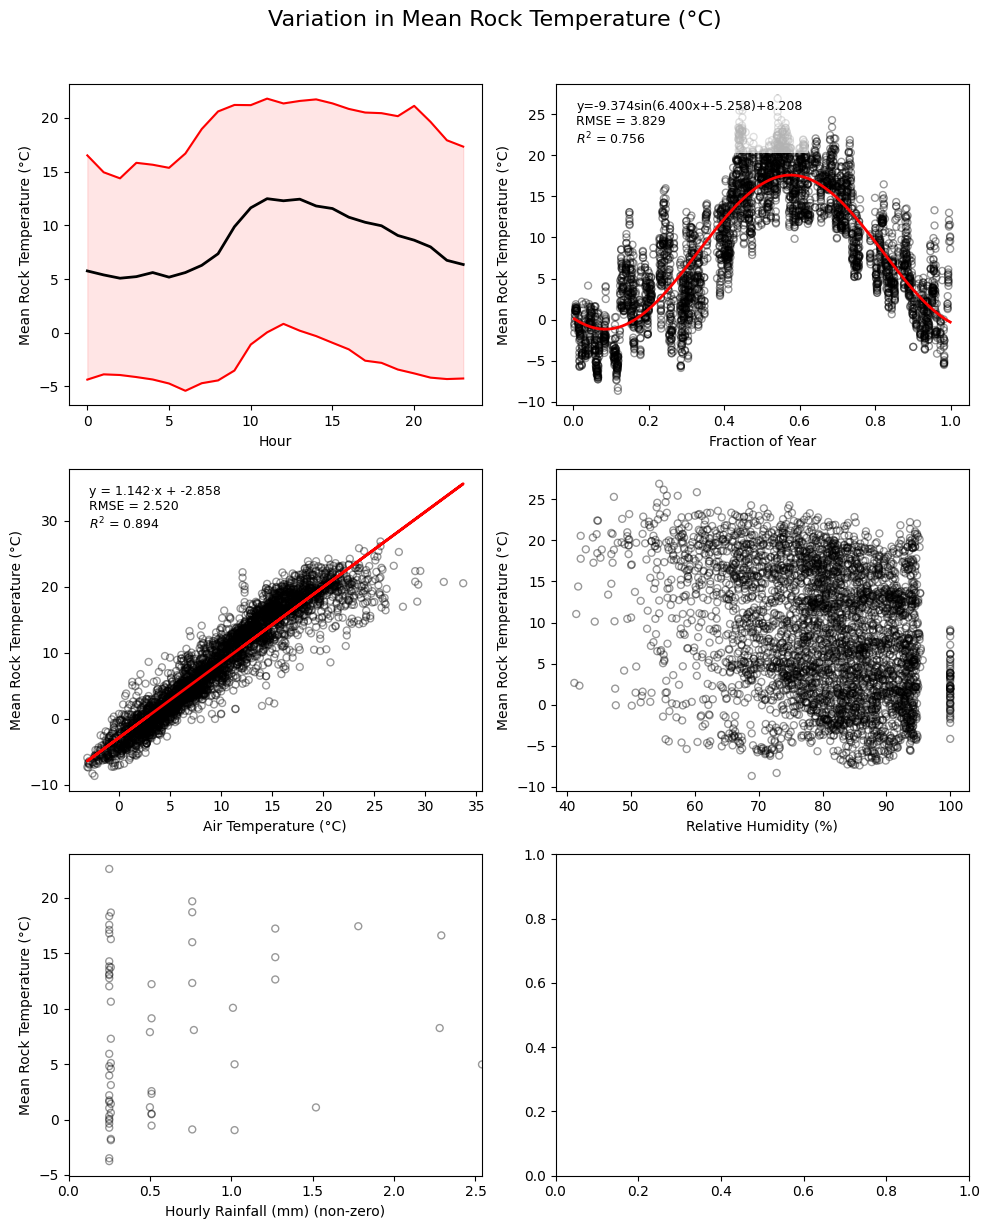

In [ ]:
#@title STR008: Matrix of Plots vs Target Variable (Iteration: 009)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from scipy.optimize import curve_fit

# Subset to variables of interest + target
df_plot = df[variables_of_interest + [target_variable]].copy()
df_plot = df_plot.dropna(subset=[target_variable])

# Determine subplot layout
n_vars = len(variables_of_interest)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

# Clean label for target variable
y_label = variable_labels.get(target_variable, target_variable)

# --- Sinusoidal model ---
def sinusoid(x, a, b, c, d):
    return a * np.sin(b * x + c) + d

for i, var in enumerate(variables_of_interest):
    ax = axes[i]
    x_label = variable_labels.get(var, var)

    # === PLOT 1: Hourly summary ===
    if i == 0 and var == "Hour_of_Day":
        hourly_stats = df_plot.groupby("Hour_of_Day")[target_variable].agg(
            mean="mean",
            p5=lambda x: np.percentile(x, 5),
            p95=lambda x: np.percentile(x, 95)
        ).reset_index()

        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["mean"],
                color="black", linewidth=2)

        ax.fill_between(hourly_stats["Hour_of_Day"],
                        hourly_stats["p5"], hourly_stats["p95"],
                        color="red", alpha=0.1)

        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["p5"],
                color="red", linewidth=1.5)
        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["p95"],
                color="red", linewidth=1.5)

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 2: Sinusoidal regression ===
    if i == 1:
        data = df_plot[[var, target_variable]].dropna()
        x = data[var].values
        y = data[target_variable].values

        guess = [1, 2*np.pi, 0, np.mean(y)]
        params, _ = curve_fit(sinusoid, x, y, p0=guess, maxfev=10000)

        x_line = np.linspace(x.min(), x.max(), 500)
        y_line = sinusoid(x_line, *params)

        y_pred = sinusoid(x, *params)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        ax.scatter(x, y,
                   facecolors='none', edgecolors='black',
                   s=25, alpha=0.4)

        ax.plot(x_line, y_line, color="red", linewidth=2)

        a, b, c, d = params
        eq_text = f"y={a:.3f}sin({b:.3f}x+{c:.3f})+{d:.3f}"

        ax.text(
            0.05, 0.95,
            f"{eq_text}\nRMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 3: Linear regression + equation + RMSE ===
    if i == 2:
        data = df_plot[[var, target_variable]].dropna()
        x = data[var].values.reshape(-1, 1)
        y = data[target_variable].values

        model = LinearRegression()
        model.fit(x, y)
        y_pred = model.predict(x)

        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = model.score(x, y)

        ax.scatter(data[var], y,
                   facecolors='none', edgecolors='black',
                   s=25, alpha=0.4)

        ax.plot(data[var], y_pred, color="red", linewidth=2)

        m = model.coef_[0]
        b = model.intercept_
        eq_text = f"y = {m:.3f}·x + {b:.3f}"

        ax.text(
            0.05, 0.95,
            f"{eq_text}\nRMSE = {rmse:.3f}\n$R^2$ = {r2:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 4: Scatter only ===
    if i == 3:
        data = df_plot[[var, target_variable]].dropna()
        x = data[var].values
        y = data[target_variable].values

        ax.scatter(x, y,
                   facecolors='none', edgecolors='black',
                   s=25, alpha=0.4)

        model = LinearRegression()
        model.fit(x.reshape(-1, 1), y)
        r2 = model.score(x.reshape(-1, 1), y)

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 5: Remove zero rainfall ===
    if i == 4 and var == "Hourly_Rainfall_Observed":
        data = df_plot[df_plot[var] > 0][[var, target_variable]].dropna()

        x = data[var].values
        y = data[target_variable].values

        ax.scatter(x, y,
                   facecolors='none', edgecolors='black',
                   s=25, alpha=0.4)

        ax.set_xlim(0, df_plot[var].max())

        ax.set_xlabel(x_label + " (non‑zero)", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === REMAINING PLOTS ===
    data = df_plot[[var, target_variable]].dropna()
    x = data[var].values.reshape(-1, 1)
    y = data[target_variable].values

    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)
    r2 = model.score(x, y)

    ax.scatter(data[var], y,
               facecolors='none', edgecolors='black',
               s=25, alpha=0.4)

    ax.plot(data[var], y_pred, color="red", linewidth=2)

    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

# Global figure title
fig.suptitle(f"Variation in {variable_labels.get(target_variable, target_variable)}",
             fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
#@title STR009: Save STR008 Figure to Google Drive (Iteration: 001)

import os
from datetime import datetime

# Path to your Google Drive folder
base_dir = "/content/drive/MyDrive/Masters_Colab_Data"
plots_dir = os.path.join(base_dir, "Plots")

# Create folder if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)

# Clean label for target variable
y_label = variable_labels.get(target_variable, target_variable)

# Datetime suffix
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Build filename
filename = f"Variation_in_{y_label.replace(' ', '_')}_{timestamp}.png"
filepath = os.path.join(plots_dir, filename)

# Save figure (fig must still exist in memory from STR008)
fig.savefig(filepath, dpi=400, bbox_inches="tight")

print(f"Plot saved to:\n{filepath}")

Plot saved to:
/content/drive/MyDrive/Masters_Colab_Data/Plots/Variation_in_Mean_Rock_Temperature_(°C)_20260319_150149.png


In [ ]:
# Variables of interest for STR008 (Ref_mean_Observed run)

variables_of_interest = [
    "Hour_of_Day",
    "Fraction_of_Year",
    "Air_Temp_Observed",
    "Relative_Humidity_Observed",
    "Hourly_Rainfall_Observed"
]

# Set the new target variable
target_variable = "Ref_Mean_Observed"

/tmp/ipykernel_160/548185934.py:126: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(neg_exp, x, y, p0=guess, maxfev=10000)


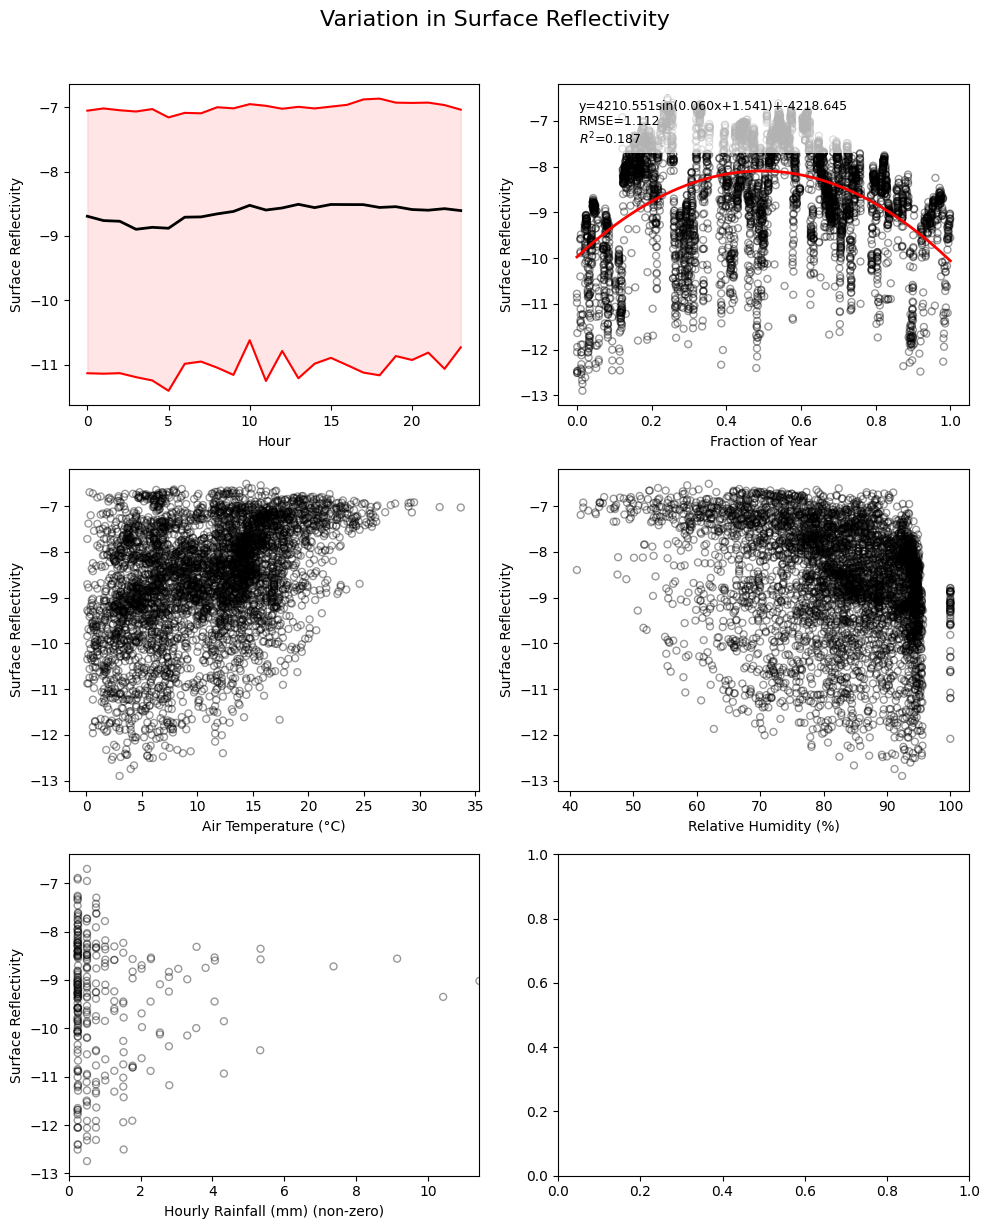

In [ ]:
#@title STR008: Matrix of Plots vs Target Variable (Iteration: 010)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from scipy.optimize import curve_fit

# Subset to variables of interest + target
df_plot = df[variables_of_interest + [target_variable]].copy()
df_plot = df_plot.dropna(subset=[target_variable])

# Determine subplot layout
n_vars = len(variables_of_interest)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

# Clean label for target variable
y_label = variable_labels.get(target_variable, target_variable)

# --- Regression models ---
def sinusoid(x, a, b, c, d):
    return a * np.sin(b * x + c) + d

def log_func(x, a, b):
    return a * np.log(x) + b

def neg_exp(x, a, b, c):
    return a * np.exp(-b * x) + c

for i, var in enumerate(variables_of_interest):
    ax = axes[i]
    x_label = variable_labels.get(var, var)

    # === PLOT 1: Hourly summary ===
    if i == 0 and var == "Hour_of_Day":
        hourly_stats = df_plot.groupby("Hour_of_Day")[target_variable].agg(
            mean="mean",
            p5=lambda x: np.percentile(x, 5),
            p95=lambda x: np.percentile(x, 95)
        ).reset_index()

        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["mean"],
                color="black", linewidth=2)

        ax.fill_between(hourly_stats["Hour_of_Day"],
                        hourly_stats["p5"], hourly_stats["p95"],
                        color="red", alpha=0.1)

        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["p5"],
                color="red", linewidth=1.5)
        ax.plot(hourly_stats["Hour_of_Day"], hourly_stats["p95"],
                color="red", linewidth=1.5)

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 2: Sinusoidal regression ===
    if i == 1:
        data = df_plot[[var, target_variable]].dropna()
        x = data[var].values
        y = data[target_variable].values

        guess = [1, 2*np.pi, 0, np.mean(y)]
        params, _ = curve_fit(sinusoid, x, y, p0=guess, maxfev=10000)

        x_line = np.linspace(x.min(), x.max(), 500)
        y_line = sinusoid(x_line, *params)

        y_pred = sinusoid(x, *params)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        ax.scatter(x, y, facecolors='none', edgecolors='black', s=25, alpha=0.4)
        ax.plot(x_line, y_line, color="red", linewidth=2)

        a, b, c, d = params
        eq_text = f"y={a:.3f}sin({b:.3f}x+{c:.3f})+{d:.3f}"

        ax.text(0.05, 0.95,
                f"{eq_text}\nRMSE={rmse:.3f}\n$R^2$={r2:.3f}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment="top",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 3: Logarithmic regression ===
    if i == 2:
        data = df_plot[[var, target_variable]].dropna()
        data = data[data[var] > 0]  # log requires positive x

        x = data[var].values
        y = data[target_variable].values

        params, _ = curve_fit(log_func, x, y, maxfev=10000)

        x_line = np.linspace(x.min(), x.max(), 500)
        y_line = log_func(x_line, *params)

        y_pred = log_func(x, *params)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        ax.scatter(x, y, facecolors='none', edgecolors='black', s=25, alpha=0.4)

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 4: Negative exponential regression ===
    if i == 3:
        data = df_plot[[var, target_variable]].dropna()

        x = data[var].values
        y = data[target_variable].values

        guess = [max(y), 0.1, min(y)]
        params, _ = curve_fit(neg_exp, x, y, p0=guess, maxfev=10000)

        x_line = np.linspace(x.min(), x.max(), 500)
        y_line = neg_exp(x_line, *params)

        y_pred = neg_exp(x, *params)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        ax.scatter(x, y, facecolors='none', edgecolors='black', s=25, alpha=0.4)

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === PLOT 5: Remove zero rainfall ===
    if i == 4 and var == "Hourly_Rainfall_Observed":
        data = df_plot[df_plot[var] > 0][[var, target_variable]].dropna()

        x = data[var].values
        y = data[target_variable].values

        ax.scatter(x, y, facecolors='none', edgecolors='black', s=25, alpha=0.4)
        ax.set_xlim(0, df_plot[var].max())

        ax.set_xlabel(x_label + " (non‑zero)", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        continue

    # === REMAINING PLOTS ===
    data = df_plot[[var, target_variable]].dropna()
    x = data[var].values.reshape(-1, 1)
    y = data[target_variable].values

    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)
    r2 = model.score(x, y)

    ax.scatter(data[var], y, facecolors='none', edgecolors='black', s=25, alpha=0.4)
    ax.plot(data[var], y_pred, color="red", linewidth=2)

    ax.text(0.05, 0.95,
            f"$R^2$={r2:.3f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)

# Global figure title
fig.suptitle(f"Variation in {variable_labels.get(target_variable, target_variable)}",
             fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
#@title STR010: Efficient 24-hour Lagged Feature Construction

import pandas as pd

# Start with a clean copy
df_lagged = df.copy()

lagged_frames = []  # store lagged blocks here

for var in variables_of_interest:
    lag_dict = {}
    for lag in range(1, 25):
        lag_dict[f"{var}_lag_{lag}h"] = df[var].shift(lag)

    # Convert this variable's lag block into a dataframe
    lagged_frames.append(pd.DataFrame(lag_dict))

# Concatenate all lagged blocks horizontally
lagged_block = pd.concat(lagged_frames, axis=1)

# Combine original df + lagged features
df_lagged = pd.concat([df_lagged, lagged_block], axis=1)

# df_lagged now contains:
# - all original variables
# - all target variables
# - 24 lagged versions of each variable of interest

df_lagged.head()

,Datetime,Air_Temp_Observed,Relative_Humidity_Observed,Hourly_Rainfall_Observed,TA_Observed,Tmean_Observed,Tmin_Observed,Tmax_Observed,Ref_Mean_Observed,Ref_Max_Observed,...,Hourly_Rainfall_Observed_lag_15h,Hourly_Rainfall_Observed_lag_16h,Hourly_Rainfall_Observed_lag_17h,Hourly_Rainfall_Observed_lag_18h,Hourly_Rainfall_Observed_lag_19h,Hourly_Rainfall_Observed_lag_20h,Hourly_Rainfall_Observed_lag_21h,Hourly_Rainfall_Observed_lag_22h,Hourly_Rainfall_Observed_lag_23h,Hourly_Rainfall_Observed_lag_24h
0,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,4.1,88.9,0.00,NaN,NaN,NaN,NaN,-10.777718,-5.037747,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-01 02:00:00,5.5,93.4,0.51,NaN,NaN,NaN,NaN,-10.970958,-5.366537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-01 03:00:00,5.8,93.7,0.00,NaN,NaN,NaN,NaN,-10.861423,-5.287881,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-01 04:00:00,5.8,92.9,0.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Variables of interest for STR008 (Ref_mean_Observed run)

variables_of_interest = [
    "Hour_of_Day",
    "Fraction_of_Year",
    "Air_Temp_Observed",
    "Relative_Humidity_Observed",
    "Hourly_Rainfall_Observed"
]

# Set the new target variable
target_variable = "Tmean_Observed"

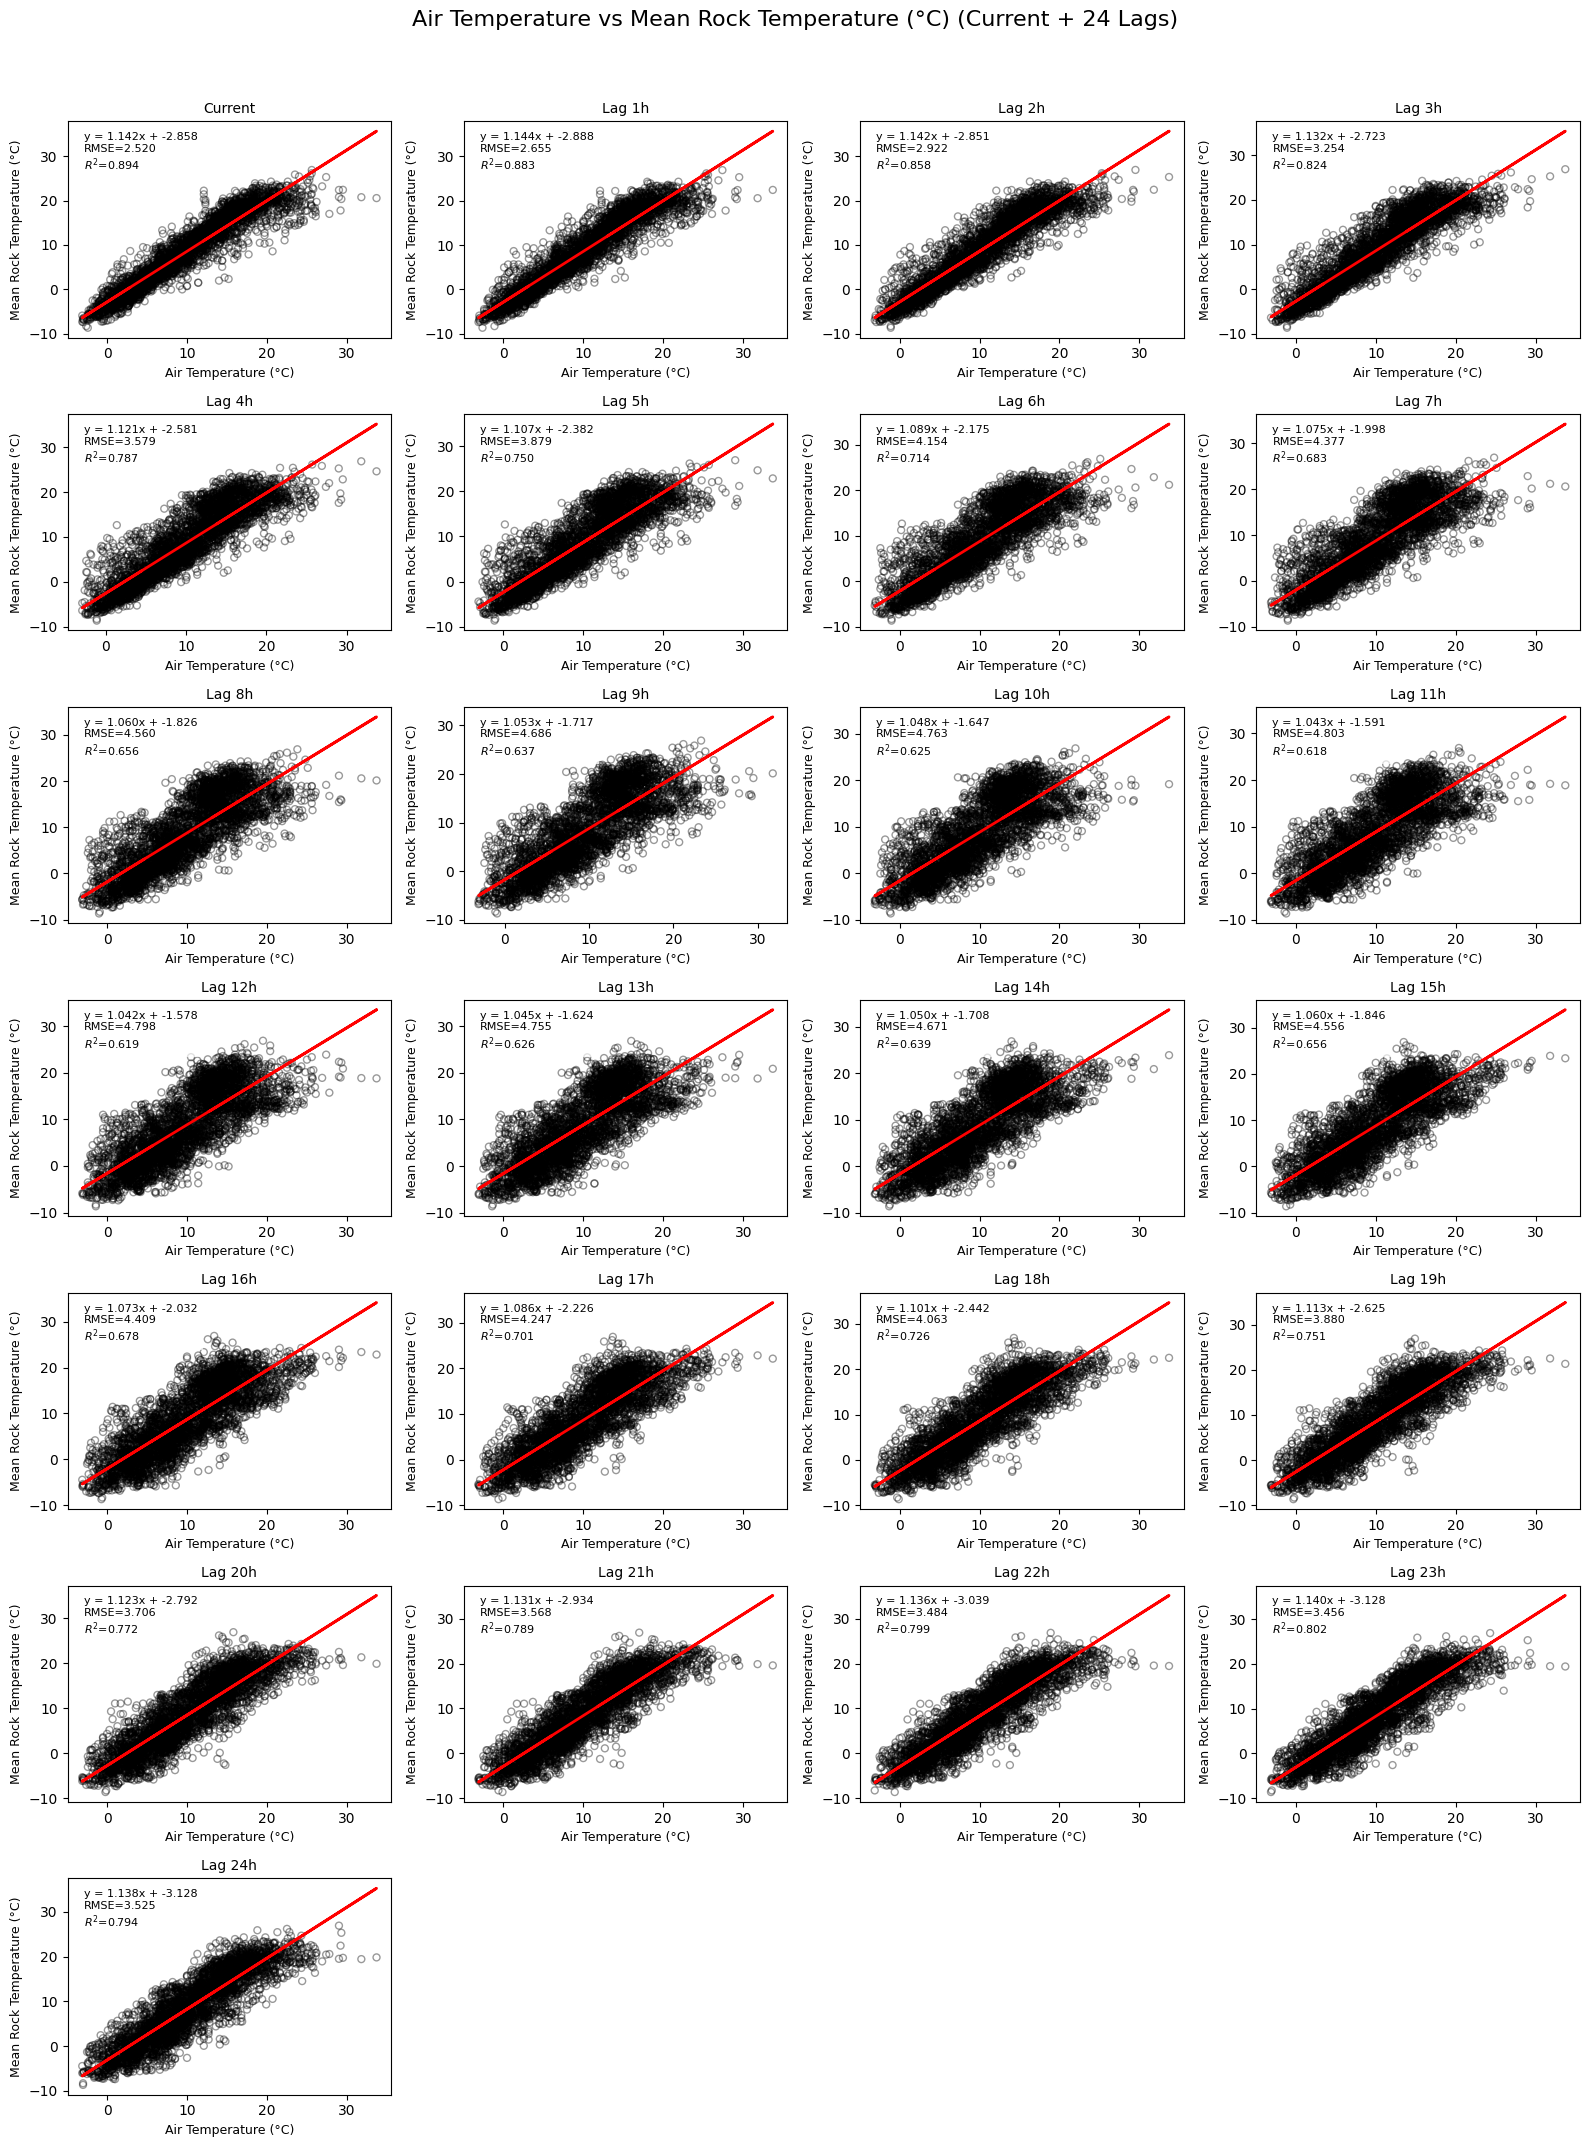

In [ ]:
#@title STR011: Air Temperature vs Target Variable for All Lags

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import re

# Identify all lagged air temperature columns
airtemp_cols = ["Air_Temp_Observed"] + \
               sorted(
                   [col for col in df_lagged.columns
                    if re.match(r"Air_Temp_Observed_lag_\d+h", col)],
                   key=lambda x: int(re.findall(r"\d+", x)[0])
               )

n_plots = len(airtemp_cols)
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

y_label = variable_labels.get(target_variable, target_variable)

for i, col in enumerate(airtemp_cols):
    ax = axes[i]

    # Extract data
    data = df_lagged[[col, target_variable]].dropna()
    x = data[col].values.reshape(-1, 1)
    y = data[target_variable].values

    # Fit linear regression
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    m = model.coef_[0]
    b = model.intercept_

    # Scatter
    ax.scatter(
        x, y,
        facecolors='none',
        edgecolors='black',
        s=25,
        alpha=0.4
    )

    # Regression line
    ax.plot(x, y_pred, color="red", linewidth=2)

    # Annotation (top-left)
    eq_text = f"y = {m:.3f}x + {b:.3f}"
    ax.text(
        0.05, 0.95,
        f"{eq_text}\nRMSE={rmse:.3f}\n$R^2$={r2:.3f}",
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    # Axis labels
    ax.set_xlabel(variable_labels.get("Air_Temp_Observed", "Air Temperature (°C)"), fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)

    # Title showing lag
    if col == "Air_Temp_Observed":
        ax.set_title("Current", fontsize=10)
    else:
        lag_hr = re.findall(r"\d+", col)[0]
        ax.set_title(f"Lag {lag_hr}h", fontsize=10)

# Remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Air Temperature vs {y_label} (Current + 24 Lags)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#@title STR012: Count complete observations in df_lagged

# Count rows with no NA in ANY column
n_complete = df_lagged.dropna().shape[0]

# Count total rows
n_total = df_lagged.shape[0]

print(f"Total rows in df_lagged: {n_total}")
print(f"Rows with no missing values: {n_complete}")
print(f"Rows removed due to NA: {n_total - n_complete}")

Total rows in df_lagged: 8760
Rows with no missing values: 2383
Rows removed due to NA: 6377


Mkaing prediction models:

In [ ]:
#@title STR014: Build Clean Modelling DataFrame and Count Complete Rows

# Columns to exclude (by name)
exclude_cols = [
    "Datetime",
    "TA_Observed",
    "Tmin_Observed",
    "Tmax_Observed",
    "Ref_Max_Observed",
    "Ref_Min_Observed",
    "Ref_Range_Observed",
    "Ref_sd_Observed",
    "Gap_Code",
    "InGap",
    "Gap_hours_Encoded",
    "Rockfall_Volume_Observed",
    "Volume_Error_Observed",
    "Rockfall_Event_Count_Observed"
]

# Build modelling dataframe
df_model = df_lagged.drop(columns=exclude_cols, errors="ignore")

# Drop rows with any NA
df_model_clean = df_model.dropna().copy()

# Report counts
n_total = df_model.shape[0]
n_clean = df_model_clean.shape[0]

print(f"Total rows before dropping NA: {n_total}")
print(f"Rows with complete data:       {n_clean}")
print(f"Rows removed due to NA:        {n_total - n_clean}")

df_model_clean.info()

Total rows before dropping NA: 8760
Rows with complete data:       2472
Rows removed due to NA:        6288
<class 'pandas.core.frame.DataFrame'>
Index: 2472 entries, 84 to 8753
Columns: 131 entries, Air_Temp_Observed to Hourly_Rainfall_Observed_lag_24h
dtypes: float64(130), int32(1)
memory usage: 2.5 MB


In [ ]:
#@title STR015: Deep Neural Network for Lagged Feature Matrix

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras

# -----------------------------
# 1. Use the cleaned modelling dataframe
# -----------------------------
df_clean = df_model_clean.copy()

print(f"Final modelling rows (no NA): {df_clean.shape[0]}")
print(f"Final modelling columns:      {df_clean.shape[1]}")

# -----------------------------
# 2. Define target + features
# -----------------------------
target = target_variable  # e.g. "Tmean_Observed" or "Ref_mean_Observed"

X = df_clean.drop(columns=[target]).values
y = df_clean[target].values

feature_names = df_clean.drop(columns=[target]).columns.tolist()

# -----------------------------
# 3. Train/Val/Test split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size:   {X_val.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

# -----------------------------
# 4. Standardise features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# -----------------------------
# 5. Build the DNN model
# -----------------------------
input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mse"]
)

model.summary()

# -----------------------------
# 6. Early stopping
# -----------------------------
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1000,
    restore_best_weights=True
)

# -----------------------------
# 7. Train the model
# -----------------------------
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=1000,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 8. Evaluate performance
# -----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_train_pred = model.predict(X_train_scaled).ravel()
y_val_pred   = model.predict(X_val_scaled).ravel()
y_test_pred  = model.predict(X_test_scaled).ravel()

print("\nDNN Performance (RMSE):")
print(f"Train RMSE: {rmse(y_train, y_train_pred):.3f}")
print(f"Val   RMSE: {rmse(y_val,   y_val_pred):.3f}")
print(f"Test  RMSE: {rmse(y_test,  y_test_pred):.3f}")

Final modelling rows (no NA): 2472
Final modelling columns:      131
Train size: 1730
Val size:   371
Test size:  371


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 256)            │        33,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,265 (637.75 KB)

 Trainable params: 163,265 (637.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 78.1271 - mse: 78.1271 - val_loss: 66.9328 - val_mse: 66.9328
Epoch 2/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 32.0488 - mse: 32.0488 - val_loss: 53.8651 - val_mse: 53.8651
Epoch 3/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 26.8797 - mse: 26.8797 - val_loss: 61.2448 - val_mse: 61.2448
Epoch 4/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 21.8318 - mse: 21.8318 - val_loss: 78.3757 - val_mse: 78.3757
Epoch 5/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 22.4504 - mse: 22.4504 - val_loss: 77.4395 - val_mse: 77.4395
Epoch 6/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 21.0459 - mse: 21.0459 - val_loss: 76.5984 - val_mse: 76.5984
Epoch 7/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 18.4637 - mse: 18.4637 - val_loss: 76.3085 - val_mse: 76.3085
Epoch 8/1000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 18.6297 - mse: 18.6297 - val_loss: 79.9143 - val_mse: 79.9143
Epoch 9/1000
28/

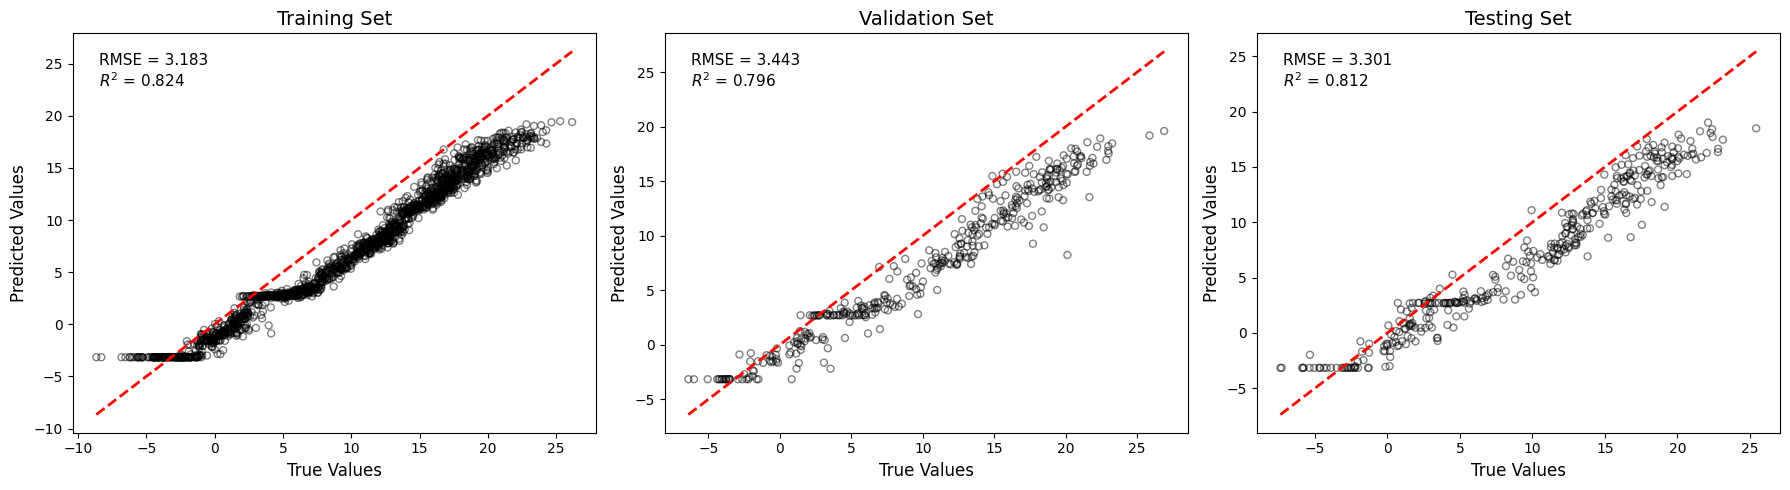

In [ ]:
#@title STR016: True vs Predicted Plots for Train, Val, Test (with R2)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Compute metrics
rmse_train = rmse(y_train, y_train_pred)
rmse_val   = rmse(y_val,   y_val_pred)
rmse_test  = rmse(y_test,  y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_val   = r2_score(y_val,   y_val_pred)
r2_test  = r2_score(y_test,  y_test_pred)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ("Training", y_train, y_train_pred, rmse_train, r2_train),
    ("Validation", y_val, y_val_pred, rmse_val, r2_val),
    ("Testing", y_test, y_test_pred, rmse_test, r2_test)
]

for ax, (title, y_true, y_pred, rmse_val, r2_val) in zip(axes, splits):

    # Scatter
    ax.scatter(
        y_true, y_pred,
        facecolors='none',
        edgecolors='black',
        alpha=0.5,
        s=25
    )

    # 1:1 line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color="red", linestyle="--", linewidth=2)

    # Labels
    ax.set_title(f"{title} Set", fontsize=14)
    ax.set_xlabel("True Values", fontsize=12)
    ax.set_ylabel("Predicted Values", fontsize=12)

    # RMSE + R2 annotation
    ax.text(
        0.05, 0.95,
        f"RMSE = {rmse_val:.3f}\n$R^2$ = {r2_val:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.tight_layout()
plt.show()

DNN without the lagged variables (simple structure)

In [ ]:
#@title STR020: Simple DNN on Non-Lagged Data

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------------
# 1. Start from the original dataframe
# -----------------------------------------
df_simple = df.copy()

# Columns to exclude
exclude_cols = [
    "Datetime",
    "TA_Observed",
    "Tmin_Observed",
    "Tmax_Observed",
    "Ref_Max_Observed",
    "Ref_Min_Observed",
    "Ref_Range_Observed",
    "Ref_sd_Observed",
    "Gap_Code",
    "InGap",
    "Gap_hours_Encoded",
    "Rockfall_Volume_Observed",
    "Volume_Error_Observed",
    "Rockfall_Event_Count_Observed"
]

df_simple = df_simple.drop(columns=exclude_cols, errors="ignore")

# Drop NA rows
df_simple_clean = df_simple.dropna().copy()

print(f"Rows after NA removal: {df_simple_clean.shape[0]}")
print(f"Columns used:          {df_simple_clean.shape[1]}")

# -----------------------------------------
# 2. Define features + target
# -----------------------------------------
target = target_variable  # e.g. "Tmean_Observed" or "Ref_mean_Observed"

X = df_simple_clean.drop(columns=[target]).values
y = df_simple_clean[target].values

feature_names = df_simple_clean.drop(columns=[target]).columns.tolist()

# -----------------------------------------
# 3. Train/Val/Test split
# -----------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size:   {X_val.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")



# -----------------------------------------
# 4. Normalise features (0–1 scaling)
# -----------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# -----------------------------------------
# 5. Build a simpler DNN
# -----------------------------------------
input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mse"]
)

model.summary()

# -----------------------------------------
# 6. Early stopping (relaxed)
# -----------------------------------------
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=60,
    restore_best_weights=True
)

# -----------------------------------------
# 7. Train
# -----------------------------------------
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# 8. Evaluate
# -----------------------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_train_pred = model.predict(X_train_scaled).ravel()
y_val_pred   = model.predict(X_val_scaled).ravel()
y_test_pred  = model.predict(X_test_scaled).ravel()

print("\nSimple DNN Performance:")
print(f"Train RMSE: {rmse(y_train, y_train_pred):.3f} | R2: {r2_score(y_train, y_train_pred):.3f}")
print(f"Val   RMSE: {rmse(y_val,   y_val_pred):.3f} | R2: {r2_score(y_val,   y_val_pred):.3f}")
print(f"Test  RMSE: {rmse(y_test,  y_test_pred):.3f} | R2: {r2_score(y_test,  y_test_pred):.3f}")

Rows after NA removal: 2683
Columns used:          11
Train size: 1878
Val size:   402
Test size:  403


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 144.7016 - mse: 144.7016 - val_loss: 118.7674 - val_mse: 118.7674
Epoch 2/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 106.8113 - mse: 106.8113 - val_loss: 78.2250 - val_mse: 78.2250
Epoch 3/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 66.5441 - mse: 66.5441 - val_loss: 47.1043 - val_mse: 47.1043
Epoch 4/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 41.5188 - mse: 41.5188 - val_loss: 29.7576 - val_mse: 29.7576
Epoch 5/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 24.7356 - mse: 24.7356 - val_loss: 16.1908 - val_mse: 16.1908
Epoch 6/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.0452 - mse: 13.0452 - val_loss: 9.0169 - val_mse: 9.0169
Epoch 7/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.3332 - mse: 8.3332 - val_loss: 6.9226 - val_mse: 6.9226
Epoch 8/300
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.0459 - mse: 7.0459 - val_loss: 6.3406 - val_mse: 6.3406
Epoch 9/300
30/30 ━━━━━━━━━━━

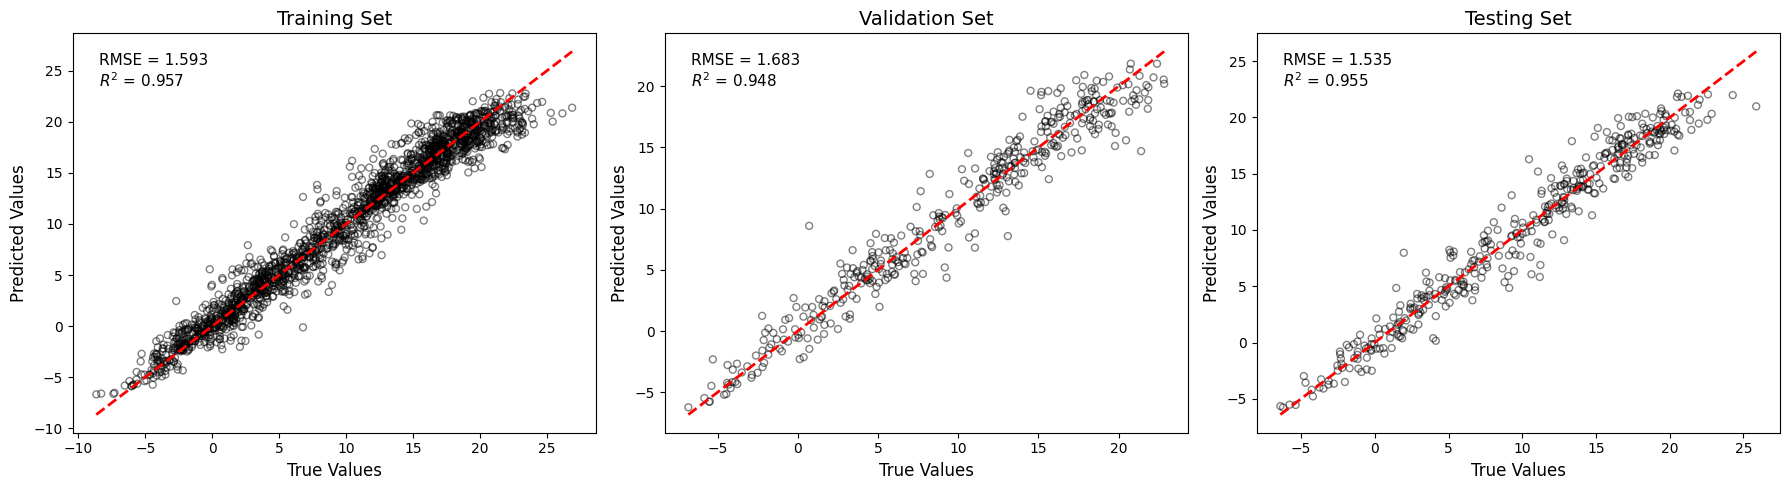

In [ ]:
#@title STR021: True vs Predicted Plots for Simple DNN (Train, Val, Test)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Compute metrics
rmse_train = rmse(y_train, y_train_pred)
rmse_val   = rmse(y_val,   y_val_pred)
rmse_test  = rmse(y_test,  y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_val   = r2_score(y_val,   y_val_pred)
r2_test  = r2_score(y_test,  y_test_pred)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ("Training", y_train, y_train_pred, rmse_train, r2_train),
    ("Validation", y_val, y_val_pred, rmse_val, r2_val),
    ("Testing", y_test, y_test_pred, rmse_test, r2_test)
]

for ax, (title, y_true, y_pred, rmse_val, r2_val) in zip(axes, splits):

    # Scatter
    ax.scatter(
        y_true, y_pred,
        facecolors='none',
        edgecolors='black',
        alpha=0.5,
        s=25
    )

    # 1:1 line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color="red", linestyle="--", linewidth=2)

    # Labels
    ax.set_title(f"{title} Set", fontsize=14)
    ax.set_xlabel("True Values", fontsize=12)
    ax.set_ylabel("Predicted Values", fontsize=12)

    # RMSE + R2 annotation
    ax.text(
        0.05, 0.95,
        f"RMSE = {rmse_val:.3f}\n$R^2$ = {r2_val:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.tight_layout()
plt.show()